In [37]:
# All libraries
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [38]:
#Task 1:

# Loading the dataset
df=pd.read_csv('clustering_dataset.csv')
df.drop(columns=['Label'],inplace=True)
df.head()

,Feature1,Feature2
0,-9.389561,6.303710
1,-9.870824,6.862056
2,-1.522144,7.549274
3,-7.140845,-5.561577
4,-11.284077,6.113819


[20172.95125854926, 9666.826543791072, 2346.8799369544413, 805.4769766778329, 729.9708698713456, 656.6217288439275, 585.089386650599, 518.4971513429718, 472.5468165704475, 433.0831044641526]


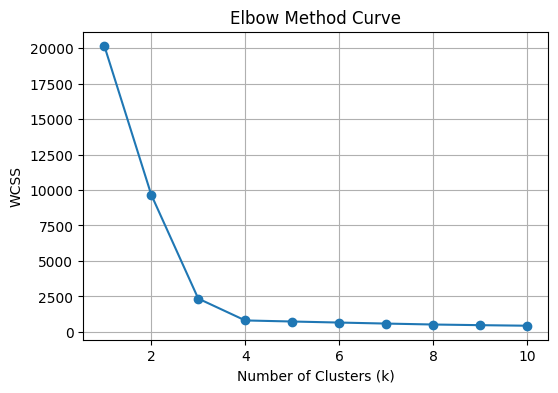

In [39]:
wcss=[]
for i in range(1,11):
    k_mean=KMeans(n_clusters=i,init='k-means++',max_iter=100,n_init='auto',random_state=42)
    k_mean.fit(df[['Feature1','Feature2']])
    wcss.append(k_mean.inertia_)
print(wcss)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method Curve')
plt.grid(True)
plt.show()



In [40]:
k_means=KMeans(n_clusters=4,init='k-means++',max_iter=100,n_init='auto',random_state=42)
y_kmeans=k_means.fit_predict(df[['Feature1','Feature2']])
print(y_kmeans)

[3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0 2 0 1 3 0 3 3 1 1 2 0 2 3 2 3 0 3
 1 3 1 2 0 3 1 0 0 3 2 3 2 1 3 1 0 1 2 3 2 2 0 3 2 2 0 1 1 1 1 1 0 1 1 3 2
 0 3 1 1 0 1 0 0 3 0 1 3 3 2 2 2 3 0 3 0 0 3 1 0 3 3 2 2 2 0 0 0 0 0 1 3 2
 0 0 0 0 2 3 1 3 1 1 1 0 3 1 3 3 0 3 1 2 0 0 0 0 2 2 3 0 1 0 2 1 0 2 2 2 2
 1 0 0 3 2 1 0 2 1 3 3 2 0 3 1 3 2 3 1 0 0 0 0 0 1 2 2 1 1 2 2 1 3 0 3 2 2
 3 1 0 2 2 1 1 1 3 2 1 1 2 2 3 0 0 1 2 0 1 1 3 1 0 0 1 1 2 3 1 3 3 0 3 3 1
 3 1 2 2 3 3 2 2 2 3 0 1 2 1 3 2 3 3 3 1 1 2 3 1 1 1 3 1 3 1 3 2 1 3 2 0 3
 0 2 0 3 0 1 2 1 2 2 0 0 1 2 2 3 3 1 0 0 2 2 2 2 1 3 2 1 2 2 1 0 1 2 0 3 0
 2 0 3 3]


In [41]:
#Task 2:
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [49]:
df = df.dropna(subset=['CustomerID'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
customer_df = df.groupby('CustomerID').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).reset_index()
customer_df.columns = ['CustomerID', 'Total_Spent', 'Total_Items']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df)
customer_df.head()


,CustomerID,Total_Spent,Total_Items
0,12346.0,0.00,0
1,12347.0,4310.00,2458
2,12348.0,1797.24,2341
3,12349.0,1757.55,631
4,12350.0,334.40,197


[390735088097.8109, 144650298286.21796, 80596291802.65836, 55084319377.8807, 38647738557.37773, 31720954011.548378, 18223033501.304295, 13666746339.209694, 11445804857.06847, 9056278498.597277]


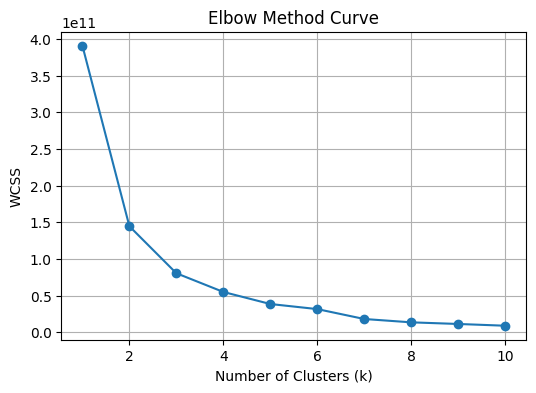

In [47]:
wcss=[]
for i in range(1,11):
    k_mean=KMeans(n_clusters=i,init='k-means++',max_iter=100,n_init='auto',random_state=42)
    k_mean.fit(customer_df[['Total_Spent','Total_Items']])
    wcss.append(k_mean.inertia_)
print(wcss)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method Curve')
plt.grid(True)
plt.show()



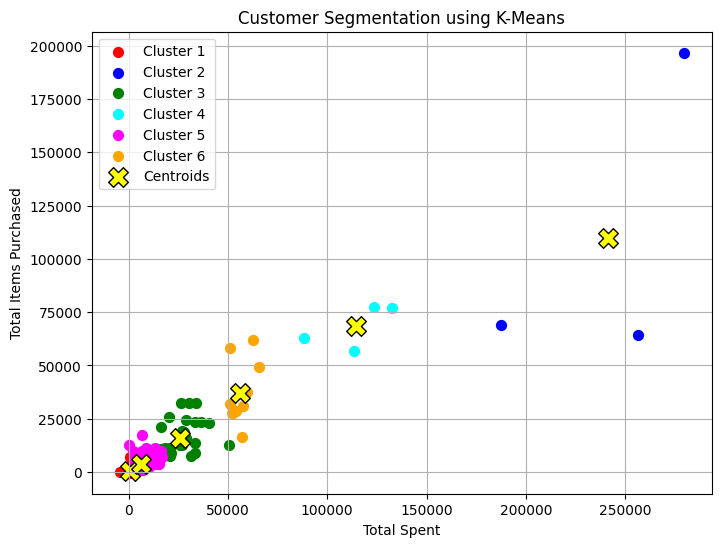

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = customer_df[['Total_Spent', 'Total_Items']]

k_means = KMeans(n_clusters=6, init='k-means++', max_iter=100, n_init='auto', random_state=42)
y_kmeans = k_means.fit_predict(X)

plt.figure(figsize=(8,6))
colors = ['red','blue','green','cyan','magenta','orange']

for i in range(6):
    plt.scatter(
        X[y_kmeans == i]['Total_Spent'], 
        X[y_kmeans == i]['Total_Items'], 
        s=50, 
        c=colors[i], 
        label=f'Cluster {i+1}'
    )
plt.scatter(
    k_means.cluster_centers_[:, 0], 
    k_means.cluster_centers_[:, 1], 
    s=200, 
    c='yellow', 
    edgecolor='black', 
    marker='X', 
    label='Centroids'
)

plt.xlabel('Total Spent')
plt.ylabel('Total Items Purchased')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.grid(True)
plt.show()


Cluster Analysis
Cluster 1 (Red)
Low Total Spent, Low Total Items
Customers who make small purchases occasionally.
Likely casual shoppers or first-time buyers.
Marketing Strategy: Send promotions or discounts to encourage larger purchases.
Cluster 2 (Blue)
High Total Spent, High Total Items
These are premium customers, who spend a lot and buy many items.
Very valuable for the business.
Marketing Strategy: Offer loyalty programs, exclusive deals, or early access to new products.
Cluster 3 (Green)
Moderate Total Spent, Moderate Total Items
Regular buyers who purchase moderately.
Marketing Strategy: Personalized recommendations or bundled offers could increase spending.
Cluster 4 (Cyan)
Moderate-High Total Spent, High Total Items
Bulk buyers who spend more than average.
Marketing Strategy: Provide bulk discounts, bundle deals, or subscription offers.
Cluster 5 (Magenta)
Low Total Spent, Moderate Total Items
Customers buying frequently but low-value items.
Marketing Strategy: Upsell or cross-sell higher-value items.
Cluster 6 (Orange)
Moderate Total Spent, Low Total Items
Customers making infrequent but moderately priced purchases.
Marketing Strategy: Engage with personalized campaigns or reminders to increase purchase frequency.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')  

numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
X = df[numeric_features].dropna()

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
print(df_pca.head())


        PC1       PC2
0  1.124841 -0.091986
1  1.118116 -0.099378
2  1.120204 -0.087388
3  1.118116 -0.099378
4  1.118116 -0.099378


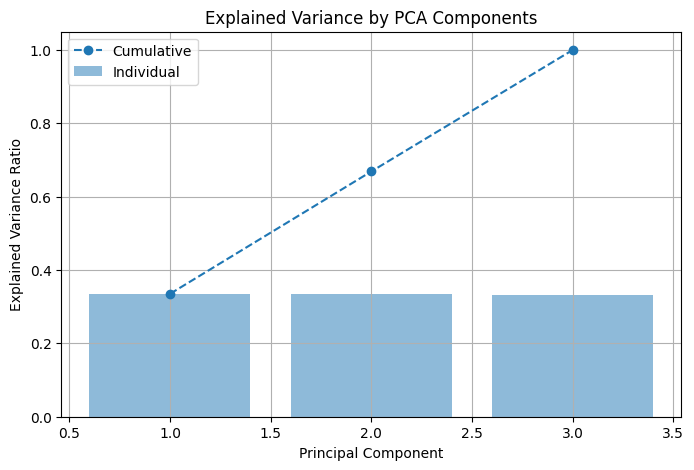

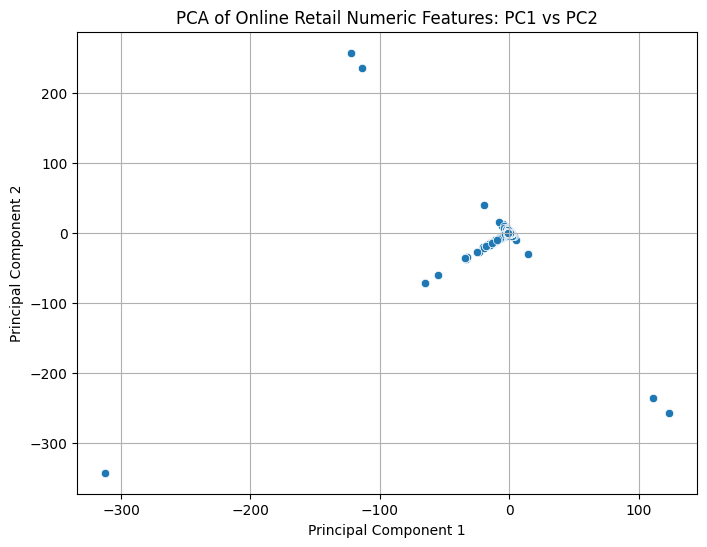

                 PC1       PC2
Quantity   -0.378551  0.791076
UnitPrice  -0.556452 -0.610313
CustomerID  0.743174 -0.054022
PC1 explains 66.88% of the variance.
PC1 contributions:
CustomerID: 0.741
UnitPrice: -0.555
Quantity: -0.378
PC2 contributions:
Quantity: 0.791
UnitPrice: -0.610
CustomerID: -0.054


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
X = df[numeric_features].dropna()

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', label='Cumulative')
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.5, label='Individual')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by PCA Components')
plt.legend()
plt.grid(True)
plt.show()

n_components = 2
pca2 = PCA(n_components=n_components)
X_reduced = pca2.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(n_components)])

loadings = pd.DataFrame(pca2.components_.T, index=numeric_features, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca)
plt.title('PCA of Online Retail Numeric Features: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

pc_feature_corr = pd.concat([df_pca, X.reset_index(drop=True)], axis=1).corr().loc[numeric_features, ['PC1','PC2']]
print(pc_feature_corr)

print(f"PC1 explains {cumulative_variance[n_components-1]*100:.2f}% of the variance.")
for pc in loadings.columns:
    sorted_load = loadings[pc].abs().sort_values(ascending=False)
    print(f"{pc} contributions:")
    for feat in sorted_load.index:
        print(f"{feat}: {loadings.loc[feat, pc]:.3f}")

df_pca.to_csv('online_retail_pca.csv', index=False)
